# **Optimizing Global Contrastive Loss with Automatic Temperature Individualization (iSogCLR)**

**Author**: Zi-Hao Qiu, Xiyuan Wei, Zhuoning Yuan, Tianbao Yang




**Introduction**

In this tutorial, we introduce the application of iSogCLR algorithm in a typical bimodal contrastive learning task. In pretraining stage, we sample a subset of the widely used [CC3M dataset](https://ai.google.com/research/ConceptualCaptions/download), which contains about 3,000,000 image-text pairs. And then we evaluate the pretrained models via zero-shot image/text retrieval on [MS-COCO](https://github.com/tylin/coco-caption) dataset.  

For the convenience of reproduction, we provide a subset of CC3M [here](https://drive.google.com/drive/folders/1IDnFIJW3FIENffgPuZcDep1_UIyzKY-D?usp=drive_link), which contains 300,000 image text pairs. We also provide the MS-COCO dataset and its jsons files [here](https://drive.google.com/drive/folders/1uwtnunMNgc_E7f8bPzs5KQnCMRDPPFB9?usp=drive_link). The experiment in this tutorial is conducted one 4 Nvidia 3090 GPUs, you can modify the **CUDA_VISIBLE_DEVICES** option and **batch_size_train** option based on your equipments.


**Reference**

 If you find this tutorial helpful in your work, please cite our [library paper](https://arxiv.org/abs/2306.03065) and the following papers:

 <pre>
@inproceedings{qiu2023isogclr,
  title={Not All Semantics are Created Equal: Contrastive Self-supervised Learning with Automatic Temperature Individualization},
  author={Qiu, Zi-Hao and Hu, Quanqi and Yuan, Zhuoning and Zhou, Denny and Zhang, Lijun and Yang, Tianbao},
  booktitle={International Conference on Machine Learning},
  pages={TBD},
  year={2023},
  organization={PMLR}
}
</pre>

# **Importing required libs**

In [ ]:
!pip install -U libauc
!pip install timm
!pip install transformers

In [ ]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "true"
os.environ["CUDA_VISIBLE_DEVICES"] = '6,7,8,9' # distributed training: '0,1,2,3'

import re
import argparse
from pathlib import Path
import json
import os
import random
import math
from functools import partial

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from torch import optim
import torchvision
from torchvision import transforms

from torch.utils.data import Dataset, Subset, DataLoader

from PIL import Image
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
Image.MAX_IMAGE_PIXELS = None

import cv2
import numpy as np

import timm
from transformers import AutoModel, AutoTokenizer

import open_clip
from open_clip.loss import ClipLoss


import libauc
from libauc.losses.contrastive import GCLoss_v2
from libauc.optimizers import iSogCLR
from libauc.utils.paper_utils import CosineLRScheduler

# **Arguments for experiments**

In [ ]:
# path to data folder
data_path = 'cc3m_subset'
train_file = 'cc3m_subset.json'

# model config
image_encoder = 'resnet50'
text_encoder = 'distilbert-base-uncased'
image_res = 256
vision_width = 768
embed_dim = 256
seed = 42

# optimizer and schedular
opt = 'adamW'
lr = 3e-4
min_lr = 1e-5
warmup = True
warmup_lr = 1e-5
weight_decay = 0.02
decay_rate = 1
epochs = 30
warmup_epochs = 20
cooldown_epochs = 0

# training & test settings
batch_size_train = 256
batch_size_test = 512
k_test = 256

# output path
output_dir = './output/'

# AMP training
use_amp = True

# loss config
temp = 0.01       # the temperature parameter for clip or sogclr
gamma = 0.8       # the parameter for the moving average estimator in sogclr/isogclr
rho = 8.0         # the rho parameter for isogclr
eta = 1e-4        # learning rate for the learnable temperature variables in isogclr
tau_init = 0.01   # the initial value of the learnable temperature variables in isogclr
beta_u = 0.9      # the momentum parameter for the graidents of the learnable temperature variables

n_gpus = torch.cuda.device_count()

val_coco_file = 'coco_val_new.json'
test_coco_file = 'coco_test_new.json'
coco_image_root = 'coco'

Path(output_dir).mkdir(parents=True, exist_ok=True)

# **Define helper functions**

In [ ]:
# we employ this function to preprocess the captions

def pre_caption(caption, max_words):
    caption = re.sub(
        r"([,.'!?\"()*#:;~])",
        '',
        caption.lower(),
    ).replace('-', ' ').replace('/', ' ').replace('<person>', 'person')

    caption = re.sub(
        r"\s{2,}",
        ' ',
        caption,
    )
    caption = caption.rstrip('\n')
    caption = caption.strip(' ')

    #truncate caption
    caption_words = caption.split(' ')
    if len(caption_words)>max_words:
        caption = ' '.join(caption_words[:max_words])

    return caption

In [ ]:
class train_set(Dataset):
    def __init__(self, ann_file, transform, image_root, max_words=30):
        self.ann = []
        for f in ann_file:
            self.ann += json.load(open(f,'r'))
        self.transform = transform
        self.image_root = image_root
        self.max_words = max_words
        self.img_ids = {}

        n = 0
        for ann in self.ann:
            img_id = ann['image_id']
            if img_id not in self.img_ids.keys():
                self.img_ids[img_id] = n
                n += 1

    def __len__(self):
        return len(self.ann)

    def __getitem__(self, index):
        ann = self.ann[index]
        image_path = os.path.join(self.image_root, ann['image'])

        image = Image.open(image_path).convert('RGB')
        image = self.transform(image)

        caption = pre_caption(ann['caption'], self.max_words)

        return image, caption, self.img_ids[ann['image_id']], index



class eval_set(Dataset):
    def __init__(self, ann_file, transform, image_root, max_words=30):
        self.ann = json.load(open(ann_file,'r'))
        self.transform = transform
        self.image_root = image_root
        self.max_words = max_words

        self.text = []
        self.image = []
        self.txt2img = {}
        self.img2txt = {}

        txt_id = 0
        for img_id, ann in enumerate(self.ann):
            self.image.append(ann['image'])
            self.img2txt[img_id] = []
            for i, caption in enumerate(ann['caption']):
                self.text.append(pre_caption(caption,self.max_words))
                self.img2txt[img_id].append(txt_id)
                self.txt2img[txt_id] = img_id
                txt_id += 1

    def __len__(self):
        return len(self.image)

    def __getitem__(self, index):
        image_path = os.path.join(self.image_root, self.ann[index]['image'])
        image = Image.open(image_path).convert('RGB')
        image = self.transform(image)

        return image, index

In [ ]:
def add_weight_decay(model, weight_decay=1e-5, skip_list=()):
    decay = []
    no_decay = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue  # frozen weights
        if len(param.shape) == 1 or name.endswith(".bias") or name in skip_list:
            no_decay.append(param)
        else:
            decay.append(param)
    return [
        {'params': no_decay, 'weight_decay': 0.},
        {'params': decay, 'weight_decay': weight_decay}]


def create_optimizer(model, opt, weight_decay=1e-5, filter_bias_and_bn=True):
    if weight_decay and filter_bias_and_bn:
        skip = {}
        if hasattr(model, 'no_weight_decay'):
            skip = model.no_weight_decay()
        parameters = add_weight_decay(model, weight_decay, skip)
        weight_decay = 0.
    else:
        parameters = model.parameters()

    opt_args = dict(lr=lr, weight_decay=weight_decay)
    optimizer = iSogCLR(parameters, mode=opt, **opt_args)

    return optimizer

In [ ]:
def create_scheduler(optimizer):
    num_epochs = epochs

    lr_scheduler = CosineLRScheduler(
        optimizer,
        t_initial = num_epochs,
        t_mul = 1.0,
        lr_min = min_lr,
        decay_rate = decay_rate,
        warmup_lr_init = warmup_lr,
        warmup_t = warmup_epochs,
        cycle_limit = 1,
        t_in_epochs = True,
        noise_range_t = None,
        noise_pct = 0.67,
        noise_std = 1.0,
        noise_seed = 42,
    )

    return lr_scheduler

# **Reproducibility**

The following functions limit the number of sources of randomness behaviors, such as model intialization, data shuffling, etcs.

In [ ]:
# fix the seed for reproducibility
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
cudnn.benchmark = True

# **Building the model**

In [ ]:
# The following class includes the image encoder, text encoder and several objectives
class Model(nn.Module):
    def __init__(self, image_encoder = None, text_encoder = None,
                 embed_dim = 256, init_model = True, bsz = 128,
                 gamma = 0.9,         # the coefficient for moving average estimator
                 temp = 0.01,         # temperature for clip or sogclr
                 rho = 8.0, eta = 0.01, tau_init = 0.01, beta_u = 0.9,  # params for isogclr
                 use_temp_net = True):    # True if you want to use temperature network for isogclr
        super().__init__()

        self.temp = temp

        self.visual_encoder = timm.create_model(image_encoder, pretrained=init_model)
        self.visual_encoder.reset_classifier(0)

        self.text_encoder = AutoModel.from_pretrained(text_encoder, local_files_only=False)

        if not init_model:
            self.text_encoder.init_weights()

        self.vision_proj = nn.Linear(self.visual_encoder.num_features, embed_dim)
        self.text_proj = nn.Linear(768, embed_dim)

        self.criterion = GCLoss_v2(tau=temp, gamma=gamma, tau_min=0.005, tau_max=0.07,
                                   rho=rho, eta=eta, enable_isogclr=True)

    def forward(self, image, text_ids, text_att_masks, idx, text_idx, epoch):
        image_embeds = self.visual_encoder(image)
        image_embeds = self.vision_proj(image_embeds)
        image_feat = F.normalize(image_embeds, dim=-1)

        text_output = self.text_encoder(text_ids, attention_mask=text_att_masks, output_hidden_states=False)
        text_embeds = self.text_proj(text_output.last_hidden_state[:,0,:])
        text_feat = F.normalize(text_embeds, dim=-1)

        loss, info = self.criterion(image_feat, text_feat, idx)

        return loss, info

# **Training functions**

In [ ]:
print_freq = 50 # user can determine how many iterations to output (e.g., 50 by default)

In [ ]:
def epoch_train(model, data_loader, optimizer, tokenizer, epoch, max_epoch, warmup_steps, device, scheduler, grad_scaler):
    # train
    model.train()

    step_size = 100
    warmup_iterations = warmup_steps * step_size

    for i,(image, text, idx, text_idx) in enumerate(data_loader):
        optimizer.zero_grad()

        image = image.to(device, non_blocking=True)
        idx = idx.to(device, non_blocking=True)
        text_idx = text_idx.to(device, non_blocking=True)
        text_input = tokenizer(text, padding='max_length', truncation=True, max_length=30, return_tensors="pt").to(device)

        if grad_scaler is None:
            loss, info = model(image, text_input.input_ids, text_input.attention_mask, idx=idx, text_idx=text_idx, epoch=epoch)
            loss.mean().backward()
            optimizer.step()
        else:
            with torch.cuda.amp.autocast():
                loss, info = model(image, text_input.input_ids, text_input.attention_mask, idx=idx, text_idx=text_idx, epoch=epoch)
            grad_scaler.scale(loss.mean()).backward()
            grad_scaler.step(optimizer)
            grad_scaler.update()

        if epoch==0 and i%step_size==0 and i<=warmup_iterations:
            scheduler.step(i//step_size)

        if i%print_freq == 0:
            lr = optimizer.param_groups[0]["lr"]
            print("Epoch:", epoch, "iteration:", i, "lr:", lr, "loss:", loss.mean().item())
            if info is not None:
                print("tau_img: %.4f, tau_txt: %.4f" % (info[0].mean(), info[1].mean()))

# **Evaluation functions**

In [ ]:
@torch.no_grad()
def evaluation(model, data_loader, tokenizer, device):
    # test
    model.eval()

    print('Computing features for evaluation...')
    texts = data_loader.dataset.text
    num_text = len(texts)
    text_bs = 256
    text_embeds = []
    for i in range(0, num_text, text_bs):
        text = texts[i: min(num_text, i+text_bs)]
        text_input = tokenizer(text, padding='max_length', truncation=True, max_length=30, return_tensors="pt").to(device)
        text_output = model.text_encoder(text_input.input_ids, attention_mask=text_input.attention_mask, output_hidden_states=False)
        text_embed = F.normalize(model.text_proj(text_output.last_hidden_state[:,0,:]), dim=-1)
        text_embeds.append(text_embed)
    text_embeds = torch.cat(text_embeds,dim=0)

    image_embeds = []
    for image, img_id in data_loader:
        image = image.to(device)
        image_feat = model.visual_encoder(image)
        image_embed = model.vision_proj(image_feat)
        image_embed = F.normalize(image_embed, dim=-1)
        image_embeds.append(image_embed)
    image_embeds = torch.cat(image_embeds,dim=0)

    sims_matrix = image_embeds @ text_embeds.t()
    score_matrix_i2t = torch.full((len(data_loader.dataset.image),len(texts)),-100.0).to(device)

    for i,sims in enumerate(sims_matrix):
        topk_sim, topk_idx = sims.topk(k=k_test, dim=0)
        score_matrix_i2t[i, topk_idx] = topk_sim

    sims_matrix = sims_matrix.t()
    score_matrix_t2i = torch.full((len(texts),len(data_loader.dataset.image)),-100.0).to(device)

    for i,sims in enumerate(sims_matrix):
        topk_sim, topk_idx = sims.topk(k=k_test, dim=0)
        score_matrix_t2i[i, topk_idx] = topk_sim

    return score_matrix_i2t.cpu().numpy(), score_matrix_t2i.cpu().numpy()



@torch.no_grad()
def itm_eval(scores_i2t, scores_t2i, txt2img, img2txt):

    #Images->Text
    ranks = np.zeros(scores_i2t.shape[0])
    for index,score in enumerate(scores_i2t):
        inds = np.argsort(score)[::-1]
        # Score
        rank = 1e20
        for i in img2txt[index]:
            tmp = np.where(inds == i)[0][0]
            if tmp < rank:
                rank = tmp
        ranks[index] = rank

    # Compute metrics
    tr1 = 100.0 * len(np.where(ranks < 1)[0]) / len(ranks)
    tr5 = 100.0 * len(np.where(ranks < 5)[0]) / len(ranks)
    tr10 = 100.0 * len(np.where(ranks < 10)[0]) / len(ranks)

    #Text->Images
    ranks = np.zeros(scores_t2i.shape[0])

    for index,score in enumerate(scores_t2i):
        inds = np.argsort(score)[::-1]
        ranks[index] = np.where(inds == txt2img[index])[0][0]

    # Compute metrics
    ir1 = 100.0 * len(np.where(ranks < 1)[0]) / len(ranks)
    ir5 = 100.0 * len(np.where(ranks < 5)[0]) / len(ranks)
    ir10 = 100.0 * len(np.where(ranks < 10)[0]) / len(ranks)

    tr_mean = (tr1 + tr5 + tr10) / 3
    ir_mean = (ir1 + ir5 + ir10) / 3
    r_mean = (tr_mean + ir_mean) / 2

    eval_result =  {'txt_r1': tr1,
                    'txt_r5': tr5,
                    'txt_r10': tr10,
                    'txt_r_mean': tr_mean,
                    'img_r1': ir1,
                    'img_r5': ir5,
                    'img_r10': ir10,
                    'img_r_mean': ir_mean,
                    'r_mean': r_mean}
    return eval_result

# **Dataset Pipeline for Bimodal Contrastive Learning**

In [ ]:
# set up the transformation, datasets and dataloaders
train_transform = transforms.Compose([
        transforms.RandomResizedCrop(image_res, scale=(0.5, 1.0), interpolation=Image.BICUBIC),
        transforms.RandomHorizontalFlip(),
        transforms.RandAugment(),
        transforms.ToTensor(),
        transforms.Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711)),
    ])

test_transform = transforms.Compose([
    transforms.Resize((image_res, image_res), interpolation=Image.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711)),
    ])

train_dataset = train_set([train_file], train_transform, data_path)
val_coco_dataset = eval_set(val_coco_file, test_transform, coco_image_root)
test_coco_dataset = eval_set(test_coco_file, test_transform, coco_image_root)

print("len of train_dataset:", len(train_dataset))
print("len of coco val/test:", len(val_coco_dataset), len(test_coco_dataset))

train_loader = DataLoader(train_dataset, batch_size=batch_size_train * n_gpus, num_workers=16, pin_memory=True,
                         shuffle=True, drop_last=True, prefetch_factor=4)
val_loader = DataLoader(val_coco_dataset, batch_size=batch_size_test, num_workers=16, pin_memory=True,
                       shuffle=False, drop_last=False, prefetch_factor=12)
test_loader = DataLoader(test_coco_dataset, batch_size=batch_size_test, num_workers=16, pin_memory=True,
                       shuffle=False, drop_last=False, prefetch_factor=12)

/home/qiuzh/.conda/envs/vlp/lib/python3.9/site-packages/torchvision/transforms/transforms.py:852: UserWarning: Argument interpolation should be of type InterpolationMode instead of int. Please, use InterpolationMode enum.
  warnings.warn(
/home/qiuzh/.conda/envs/vlp/lib/python3.9/site-packages/torchvision/transforms/transforms.py:287: UserWarning: Argument interpolation should be of type InterpolationMode instead of int. Please, use InterpolationMode enum.
  warnings.warn(


len of train_dataset: 300000
len of coco val/test: 5000 5000


# **Pretraining and evaluation for iSogCLR**

In [ ]:
# create the model and wrap it in DDP
tokenizer = AutoTokenizer.from_pretrained(text_encoder, local_files_only=False)
model = Model(image_encoder=image_encoder, text_encoder=text_encoder, embed_dim=embed_dim,
              init_model=True, bsz=batch_size_train,
              gamma=gamma, temp=temp, rho=rho, eta=eta, tau_init=tau_init, beta_u=beta_u)

model = model.cuda()

/home/qiuzh/.conda/envs/vlp/lib/python3.9/site-packages/transformers/configuration_utils.py:336: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /distilbert-base-uncased/resolve/main/config.json (Caused by ProxyError('Your proxy appears to only use HTTP and not HTTPS, try changing your proxy URL to be HTTP. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#https-proxy-error-http-proxy', SSLError(SSLError(1, '[SSL: WRONG_VERSION_NUMBER] wrong version number (_ssl.c:1129)'))))
Some weights of the model checkpoint at distilbert-base-uncased were not used when initializing DistilBertModel: ['vocab_transform.weight', 'vocab_layer_norm.weight'

In [ ]:
if n_gpus > 1:
    print("Using", n_gpus, "GPUs")
    model = nn.DataParallel(model)

Using 4 GPUs


In [ ]:
# set up the optimizer and objective function
optimizer = create_optimizer(model, opt, weight_decay)
lr_scheduler = create_scheduler(optimizer)

if use_amp:
    grad_scaler = torch.cuda.amp.GradScaler()
else:
    grad_scaler = None

# training loop
for epoch in range(0, epochs):
    train_stats = epoch_train(model, train_loader, optimizer, tokenizer, epoch, epochs,
                              warmup_epochs, torch.device('cuda'), lr_scheduler, grad_scaler)

    # evaluate the model on ms-coco data
    try:
        score_val_i2t_coco, score_val_t2i_coco = evaluation(model.module, val_loader, tokenizer,  torch.device('cuda'))
        score_test_i2t_coco, score_test_t2i_coco = evaluation(model.module, test_loader, tokenizer,  torch.device('cuda'))
    except:
        # for non-distributed training
        score_val_i2t_coco, score_val_t2i_coco = evaluation(model, val_loader, tokenizer,  torch.device('cuda'))
        score_test_i2t_coco, score_test_t2i_coco = evaluation(model, test_loader, tokenizer,  torch.device('cuda'))
    print("Epoch:", epoch)
    val_result_coco = itm_eval(score_val_i2t_coco, score_val_t2i_coco, val_loader.dataset.txt2img, val_loader.dataset.img2txt)
    print("coco val:", val_result_coco)
    test_result_coco = itm_eval(score_test_i2t_coco, score_test_t2i_coco, test_loader.dataset.txt2img, test_loader.dataset.img2txt)
    print("coco test:", test_result_coco)

    lr_scheduler.step(epoch+warmup_epochs+1)

/home/qiuzh/.conda/envs/vlp/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '


Epoch: 0 iteration: 0 lr: 1e-05 loss: 24.701007843017578
tau_img: 0.0100, tau_txt: 0.0100
Epoch: 0 iteration: 50 lr: 1e-05 loss: 10.574981689453125
tau_img: 0.0100, tau_txt: 0.0100
Epoch: 0 iteration: 100 lr: 2.45e-05 loss: 4.697925567626953
tau_img: 0.0100, tau_txt: 0.0100
Epoch: 0 iteration: 150 lr: 2.45e-05 loss: 1.9576847553253174
tau_img: 0.0100, tau_txt: 0.0100
Epoch: 0 iteration: 200 lr: 3.899999999999999e-05 loss: 1.0460829734802246
tau_img: 0.0100, tau_txt: 0.0100
Epoch: 0 iteration: 250 lr: 3.899999999999999e-05 loss: 0.5043810606002808
tau_img: 0.0100, tau_txt: 0.0100
Computing features for evaluation...
Computing features for evaluation...
Epoch: 0
coco val: {'txt_r1': 4.1, 'txt_r5': 13.8, 'txt_r10': 21.34, 'txt_r_mean': 13.079999999999998, 'img_r1': 2.0591763294682126, 'img_r5': 7.860855657736905, 'img_r10': 13.13874450219912, 'img_r_mean': 7.686258829801413, 'r_mean': 10.383129414900706}
coco test: {'txt_r1': 4.2, 'txt_r5': 12.7, 'txt_r10': 20.2, 'txt_r_mean': 12.36666666

coco test: {'txt_r1': 17.68, 'txt_r5': 40.18, 'txt_r10': 52.56, 'txt_r_mean': 36.806666666666665, 'img_r1': 11.75529788084766, 'img_r5': 30.151939224310276, 'img_r10': 41.89924030387845, 'img_r_mean': 27.935492469678792, 'r_mean': 32.37107956817273}
Epoch: 7 iteration: 0 lr: 0.00026275599969422214 loss: -0.4518427550792694
tau_img: 0.0070, tau_txt: 0.0067
Epoch: 7 iteration: 50 lr: 0.00026275599969422214 loss: 0.2819710075855255
tau_img: 0.0070, tau_txt: 0.0067
Epoch: 7 iteration: 100 lr: 0.00026275599969422214 loss: 0.05290326103568077
tau_img: 0.0070, tau_txt: 0.0067
Epoch: 7 iteration: 150 lr: 0.00026275599969422214 loss: -0.008920110762119293
tau_img: 0.0070, tau_txt: 0.0067
Epoch: 7 iteration: 200 lr: 0.00026275599969422214 loss: 0.2930781841278076
tau_img: 0.0070, tau_txt: 0.0067
Epoch: 7 iteration: 250 lr: 0.00026275599969422214 loss: 0.14736725389957428
tau_img: 0.0070, tau_txt: 0.0067
Computing features for evaluation...
Computing features for evaluation...
Epoch: 7
coco val: 

Epoch: 13 iteration: 250 lr: 0.00018514719516857505 loss: -0.5934573411941528
tau_img: 0.0068, tau_txt: 0.0066
Computing features for evaluation...
Computing features for evaluation...
Epoch: 13
coco val: {'txt_r1': 19.1, 'txt_r5': 40.84, 'txt_r10': 53.04, 'txt_r_mean': 37.660000000000004, 'img_r1': 12.538984406237505, 'img_r5': 31.36345461815274, 'img_r10': 42.94282287085166, 'img_r_mean': 28.9484206317473, 'r_mean': 33.304210315873654}
coco test: {'txt_r1': 18.26, 'txt_r5': 40.74, 'txt_r10': 53.12, 'txt_r_mean': 37.373333333333335, 'img_r1': 12.810875649740105, 'img_r5': 31.955217912834865, 'img_r10': 43.398640543782484, 'img_r_mean': 29.388244702119152, 'r_mean': 33.380789017726244}
Epoch: 14 iteration: 0 lr: 0.00017015662717380974 loss: -1.136932611465454
tau_img: 0.0069, tau_txt: 0.0067
Epoch: 14 iteration: 50 lr: 0.00017015662717380974 loss: -1.2352209091186523
tau_img: 0.0071, tau_txt: 0.0068
Epoch: 14 iteration: 100 lr: 0.00017015662717380974 loss: -0.3656700551509857
tau_img: 

Epoch: 20 iteration: 100 lr: 8.250000000000001e-05 loss: -5.427042484283447
tau_img: 0.0088, tau_txt: 0.0085
Epoch: 20 iteration: 150 lr: 8.250000000000001e-05 loss: -5.009304046630859
tau_img: 0.0087, tau_txt: 0.0085
Epoch: 20 iteration: 200 lr: 8.250000000000001e-05 loss: -5.154559135437012
tau_img: 0.0088, tau_txt: 0.0084
Epoch: 20 iteration: 250 lr: 8.250000000000001e-05 loss: -5.245851993560791
tau_img: 0.0087, tau_txt: 0.0085
Computing features for evaluation...
Computing features for evaluation...
Epoch: 20
coco val: {'txt_r1': 21.16, 'txt_r5': 43.64, 'txt_r10': 55.96, 'txt_r_mean': 40.25333333333333, 'img_r1': 13.914434226309476, 'img_r5': 33.954418232706914, 'img_r10': 45.64574170331867, 'img_r_mean': 31.171531387445018, 'r_mean': 35.71243236038917}
coco test: {'txt_r1': 20.46, 'txt_r5': 43.9, 'txt_r10': 55.6, 'txt_r_mean': 39.98666666666667, 'img_r1': 14.166333466613354, 'img_r5': 34.44622151139544, 'img_r10': 45.7936825269892, 'img_r_mean': 31.46874583499933, 'r_mean': 35.72

Epoch: 27 iteration: 0 lr: 1.7096805137202738e-05 loss: -12.180134773254395
tau_img: 0.0114, tau_txt: 0.0113
Epoch: 27 iteration: 50 lr: 1.7096805137202738e-05 loss: -12.57005500793457
tau_img: 0.0112, tau_txt: 0.0110
Epoch: 27 iteration: 100 lr: 1.7096805137202738e-05 loss: -12.195676803588867
tau_img: 0.0115, tau_txt: 0.0113
Epoch: 27 iteration: 150 lr: 1.7096805137202738e-05 loss: -13.575706481933594
tau_img: 0.0116, tau_txt: 0.0113
Epoch: 27 iteration: 200 lr: 1.7096805137202738e-05 loss: -14.225406646728516
tau_img: 0.0115, tau_txt: 0.0113
Epoch: 27 iteration: 250 lr: 1.7096805137202738e-05 loss: -11.519415855407715
tau_img: 0.0113, tau_txt: 0.0111
Computing features for evaluation...
Computing features for evaluation...
Epoch: 27
coco val: {'txt_r1': 20.72, 'txt_r5': 44.04, 'txt_r10': 55.4, 'txt_r_mean': 40.053333333333335, 'img_r1': 14.186325469812076, 'img_r5': 33.71451419432227, 'img_r10': 45.63374650139944, 'img_r_mean': 31.178195388511266, 'r_mean': 35.6157643609223}
coco te

# **Visualization**

In order to compare the performance of different algorithms, we also train CLIP models using OpenCLIP, and the notebook is available [here](https://colab.research.google.com/drive/1Xapa9XDu9RxKCxlDwzIogHiJggil0PcL). Here we demonstrate the training curves of the mean validation recall values for CLIP and iSogCLR.

In [ ]:
clip_recall_vals = [9.56793, 26.4037, 29.3343, 29.7682, 30.5586, 30.8398, 30.8938, 31.5624, 30.5864, 31.1057, 31.775, 31.0977, 31.8895, 31.0098, 31.2123, 31.745, 31.8129, 32.0983, 31.163, 31.7523, 32.1975, 32.2302, 32.5441, 32.3621, 32.6608, 32.7541, 32.7528, 32.4954, 32.9994, 32.7601]
isogclr_recall_vals = [10.3831, 22.1452, 26.797, 29.2797, 30.6854, 31.7613, 32.4364, 32.3897, 31.5938, 32.287, 32.5756, 33.0849, 33.1855, 33.3042, 33.3853, 34.8619, 34.9766, 34.6912, 35.5051, 35.1258, 35.7124, 35.2958, 35.6323, 35.5724, 35.2651, 35.6277, 35.599, 35.6157, 35.641, 35.5077]

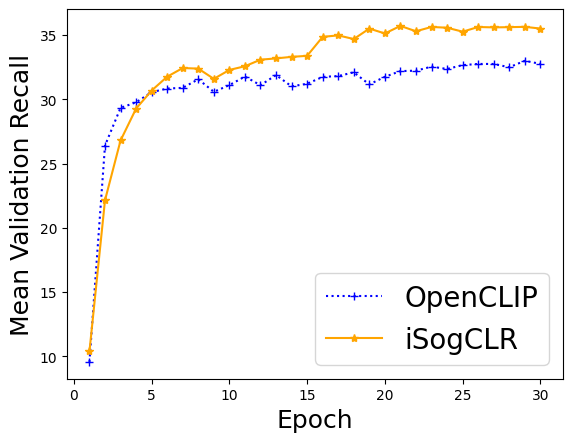

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, 31)

plt.plot(epochs, clip_recall_vals, label='OpenCLIP', ls=':', marker='+', color='blue')
plt.plot(epochs, isogclr_recall_vals, label='iSogCLR', marker='*', color='orange')

plt.ylabel('Mean Validation Recall', fontsize=18)
plt.xlabel('Epoch', fontsize=18)

plt.legend(fontsize=20)

plt.show()